<a href="https://colab.research.google.com/github/Hayatullah650/Agentic-AI-workflows/blob/main/non_LLMs_base_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict

In [26]:
#define state
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [27]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight']
    height = state['height']

    bmi = weight / (height ** 2)
    state['bmi'] =  round(bmi, 2)
    return state

In [28]:
def labeled_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = "Underweight"
    elif 18.5 <= bmi < 25:
        state['category'] = "normal"
    elif 25 <= bmi < 30:
        state['category'] = "overweight"
    else:
        state['category'] = "Obese"

    return state


In [29]:
# define graph
graph = StateGraph(BMIState)

# add nodes
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('labeled_bmi', labeled_bmi)
# add edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi' , 'labeled_bmi')
graph.add_edge('calculate_bmi', END)
#compile graph
workflow = graph.compile()


In [30]:
# excute the graph
intail_state = workflow.invoke({'weight': 70, 'height': 1.75})

final_state = workflow.invoke(intail_state)
print(final_state)


{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'normal'}


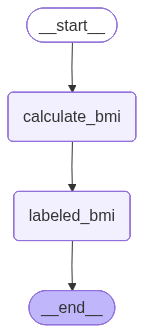

In [31]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))